2026-06-07 18:29:39,276 - INFO - Credit Scoring Pipeline Initialized Successfully.
2026-06-07 18:29:39,276 - INFO - Training production model framework...



RECRUITER REPORT: PRODUCTION CREDENTIALS
              precision    recall  f1-score   support

           0       0.98      0.88      0.93        52
           1       0.98      1.00      0.99       248

    accuracy                           0.98       300
   macro avg       0.98      0.94      0.96       300
weighted avg       0.98      0.98      0.98       300



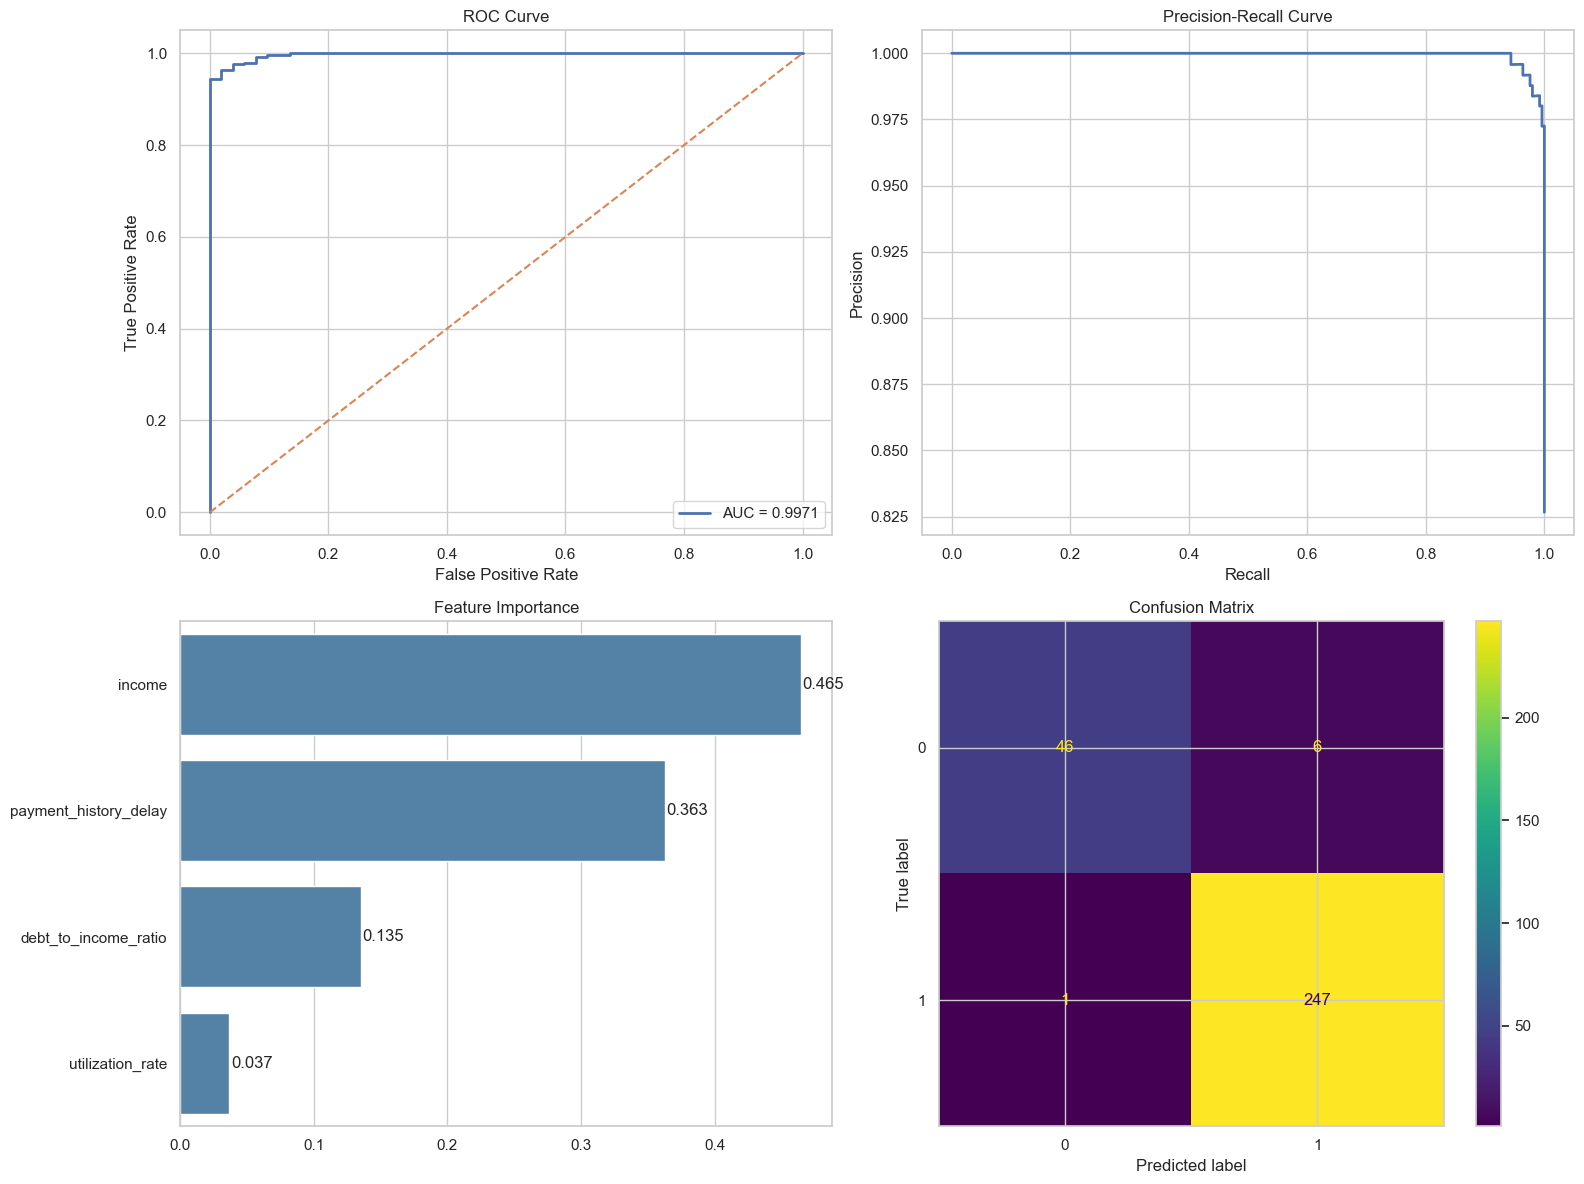

In [8]:
import os
import logging
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    roc_curve,
    auc,
    precision_recall_curve,
    ConfusionMatrixDisplay
)

# =========================
# Logging
# =========================
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s'
)

# =========================
# Pipeline Class
# =========================
class CreditScoringPipeline:
    def __init__(self):
        self.pipeline = Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
            ('classifier', RandomForestClassifier(
                n_estimators=150,
                max_depth=10,
                class_weight='balanced',
                random_state=42,
                n_jobs=-1
            ))
        ])
        logging.info("Credit Scoring Pipeline Initialized Successfully.")

    def fit(self, X, y):
        logging.info("Training production model framework...")
        self.pipeline.fit(X, y)

    def predict(self, X):
        return self.pipeline.predict(X)

    def predict_proba(self, X):
        return self.pipeline.predict_proba(X)[:, 1]

    def generate_visual_analytics(self, X_test, y_test, y_pred, y_proba, feature_names):
        sns.set_theme(style="whitegrid")

        fig, axes = plt.subplots(2, 2, figsize=(16, 12))

        # =========================
        # 1. ROC Curve
        # =========================
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        roc_auc = auc(fpr, tpr)

        axes[0, 0].plot(fpr, tpr, lw=2, label=f'AUC = {roc_auc:.4f}')
        axes[0, 0].plot([0, 1], [0, 1], linestyle='--')
        axes[0, 0].set_title('ROC Curve')
        axes[0, 0].set_xlabel('False Positive Rate')
        axes[0, 0].set_ylabel('True Positive Rate')
        axes[0, 0].legend()

        # =========================
        # 2. Precision-Recall Curve
        # =========================
        precision, recall, _ = precision_recall_curve(y_test, y_proba)

        axes[0, 1].plot(recall, precision, lw=2)
        axes[0, 1].set_title('Precision-Recall Curve')
        axes[0, 1].set_xlabel('Recall')
        axes[0, 1].set_ylabel('Precision')

        # =========================
        # 3. Feature Importance
        # =========================
        importances = self.pipeline.named_steps['classifier'].feature_importances_
        indices = np.argsort(importances)[::-1]

        sorted_features = np.array(feature_names)[indices]
        sorted_importances = importances[indices]

        sns.barplot(
            x=sorted_importances,
            y=sorted_features,
            color='steelblue',
            ax=axes[1, 0]
        )

        axes[1, 0].set_title('Feature Importance')

        for i, v in enumerate(sorted_importances):
            axes[1, 0].text(v + 0.001, i, f"{v:.3f}", va='center')

        # =========================
        # 4. Confusion Matrix
        # =========================
        ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=axes[1, 1])
        axes[1, 1].set_title("Confusion Matrix")

        # =========================
        # SHOW + SAVE (IMPORTANT FIX)
        # =========================
        plt.tight_layout()

        # Save image
        plt.savefig('credit_scoring_analytics.png', dpi=300)

        # Show in Jupyter (THIS WAS MISSING)
        plt.show()

        # Close
        plt.close()


# =========================
# Main
# =========================
def main():
    np.random.seed(42)
    num_samples = 1500

    X_mock = pd.DataFrame({
        'income': np.random.normal(60000, 18000, num_samples),
        'debt_to_income_ratio': np.random.uniform(0.1, 0.8, num_samples),
        'payment_history_delay': np.random.poisson(0.5, num_samples),
        'utilization_rate': np.random.uniform(0.05, 0.95, num_samples)
    })

    y_mock = (
        X_mock['income'] * 0.4
        - X_mock['debt_to_income_ratio'] * 15000
        - X_mock['payment_history_delay'] * 8000
        > 5000
    ).astype(int)

    X_train, X_test, y_train, y_test = train_test_split(
        X_mock,
        y_mock,
        test_size=0.2,
        stratify=y_mock,
        random_state=42
    )

    model = CreditScoringPipeline()
    model.fit(X_train, y_train)

    predictions = model.predict(X_test)
    probabilities = model.predict_proba(X_test)

    print("\n" + "=" * 60)
    print("RECRUITER REPORT: PRODUCTION CREDENTIALS")
    print("=" * 60)
    print(classification_report(y_test, predictions))

    model.generate_visual_analytics(
        X_test,
        y_test,
        predictions,
        probabilities,
        X_mock.columns.tolist()
    )


if __name__ == "__main__":
    main()